# Tests and validations

In [ ]:
import sys, os
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

from pyfrechet.metric_spaces import MetricData, Sphere, Spheroid, sphere_to_spheroid, spheroid_to_sphere, angles_to_spheroid

from pyfrechet.regression.bagged_regressor import BaggedRegressor
from pyfrechet.regression.d_trees import d_Tree
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from geomstats.geometry.hypersphere import Hypersphere
from geomstats.learning.frechet_mean import FrechetMean
import matplotlib.cm as cm

from pyfrechet.metric_spaces.py_linz_geod import Ellipsoid
from pygeodesy import EcefKarney
import pandas as pd

#### In this notebook, we show validations and tests of several important aspects of the experiments
#### These plots are illustrative, to provide an intuition of how the distance on the spheroid works. They were also used to validate the implemented distance

In [242]:
sphere = Sphere(2)  # Sphere
spheroid = Spheroid(a=0.5, c=1.0)  # Prolate spheroid

def create_spheroid_grid(grid_size: int=200, a: float=1.0, c: float=1.0) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    This is the grid we use for the spheroid plot wireframes
    """
    # Create a mesh grid for the spheroid
    u = np.linspace(0, np.pi, 2*grid_size)
    v = np.linspace(0, 2 * np.pi, grid_size)
    u, v = np.meshgrid(u, v)

    # Convert to spheroid using angles_to_spheroid
    spheroid_points = angles_to_spheroid(
        np.stack([u.flatten(), v.flatten()], axis=-1), a=a, c=c
    )
    x_spheroid = spheroid_points[:, 0].reshape(u.shape)
    y_spheroid = spheroid_points[:, 1].reshape(u.shape)
    z_spheroid = spheroid_points[:, 2].reshape(u.shape)
    
    return x_spheroid, y_spheroid, z_spheroid

def generate_random_points(n_points=10, concentration=1.0, seed=1):
    """Generate random points concentrated in a region of the sphere."""
    np.random.seed(seed)
    theta = np.random.vonmises(0, concentration, n_points)
    phi = np.random.vonmises(np.pi/2, concentration, n_points)
    
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    
    return np.column_stack([x, y, z])

def visualize_mean_computation(points, weights, n_steps=20, init = True, seed = 1):
    """Visualize the Fréchet mean computation steps."""
    # Initialize with extrinsic mean
    np.random.seed(seed)

    if init:
        extrinsic_mean = weights.dot(points)
        init_mean = extrinsic_mean / np.linalg.norm(extrinsic_mean)
        init_mean = weights.dot(points) / np.sum(weights)
        init_mean = init_mean / np.linalg.norm(init_mean)
        # Store steps and weights
        mean_steps = [init_mean]
        current_mean = init_mean
        
        # Set random seed to ensure consistent optimization path
        np.random.seed(seed)
        
        # Run multiple fits with increasing max_iter
        for i in range(1, n_steps + 1):        
            # Create new FrechetMean object for this iteration
            mean_calculator = FrechetMean(space=sphere.manifold)
            mean_calculator.set(
                init_point=init_mean,  # Always use same init point
                max_iter=i,  # Increase max iterations each time
                verbose=True
            )
            
            # Fit and get estimate
            mean_calculator.fit(points, weights=weights)
            current_mean = mean_calculator.estimate_
            
            # Add to steps if it's different from last mean
            mean_steps.append(current_mean)

    else:            
        mean_steps = []
        # Run multiple fits with increasing max_iter
        for i in range(0, n_steps + 1):        
            # Create new FrechetMean object for this iteration
            mean_calculator = FrechetMean(space=sphere.manifold)
            mean_calculator.set(
                max_iter=i,  # Increase max iterations each time
                verbose=True
            )
            
            # Fit and get estimate
            mean_calculator.fit(points, weights=weights)
            current_mean = mean_calculator.estimate_
            
            # Add to steps if it's different from last mean
            mean_steps.append(current_mean)
        
    return np.array(mean_steps)

#### These plots are illustrative, to provide an intuition of how the distance on the spheroid works. They were also used to validate the implemented distance

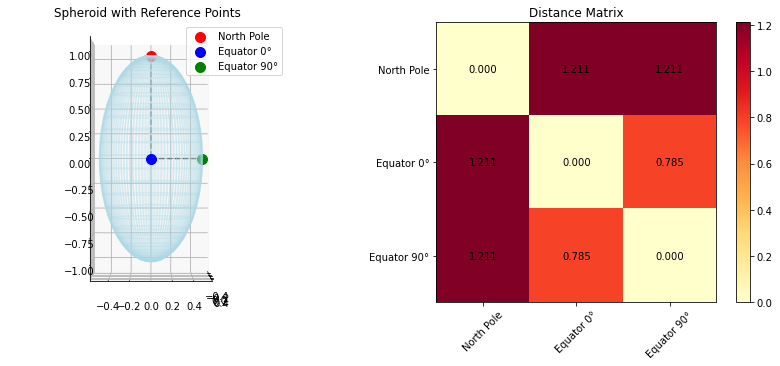


Distances:
North Pole to Equator 0°: 1.211
North Pole to Equator 90°: 1.211
Equator 0° to Equator 90°: 0.785


In [125]:
# Create spheroid with a=0.5 and c=1
a = 0.5
c = 1.0
M_spheroid = Spheroid(a=a, c=c)

# Create reference points
north_pole = np.array([0, 0, c])  # North pole
equator_0 = np.array([a, 0, 0])   # Point on equator at 0° longitude
equator_90 = np.array([0, a, 0])  # Point on equator at 90° longitude

# Create visualization
fig = plt.figure(figsize=(12, 5))

# First subplot: 3D visualization
ax1 = fig.add_subplot(121, projection='3d')

# Plot spheroid wireframe
x_spheroid, y_spheroid, z_spheroid = create_spheroid_grid(grid_size=50, a=a, c=c)
ax1.plot_wireframe(x_spheroid, y_spheroid, z_spheroid, color='lightblue', alpha=0.3, zorder=0)

# Plot reference points
ax1.scatter(*north_pole, color='red', s=100, label='North Pole')
ax1.scatter(*equator_0, color='blue', s=100, label='Equator 0°')
ax1.scatter(*equator_90, color='green', s=100, label='Equator 90°')

Axes3D.set_aspect(ax1, 'equal')
# Add lines between points
ax1.plot([north_pole[0], equator_0[0]], [north_pole[1], equator_0[1]], 
         [north_pole[2], equator_0[2]], 'k--', alpha=0.5, zorder=1)
ax1.plot([equator_0[0], equator_90[0]], [equator_0[1], equator_90[1]], 
         [equator_0[2], equator_90[2]], 'k--', alpha=0.5, zorder=1)

ax1.set_title('Spheroid with Reference Points')
ax1.legend()
ax1.view_init(elev=0, azim=0)

# Second subplot: Distance matrix
ax2 = fig.add_subplot(122)

# Calculate distances between points
points = [north_pole, equator_0, equator_90]
n_points = len(points)
dist_matrix = np.zeros((n_points, n_points))

for i in range(n_points):
    for j in range(n_points):
        dist_matrix[i,j] = M_spheroid.d(points[i], points[j])

# Plot distance matrix
im = ax2.imshow(dist_matrix, cmap='YlOrRd')
plt.colorbar(im)

# Add labels
point_labels = ['North Pole', 'Equator 0°', 'Equator 90°']
ax2.set_xticks(range(n_points))
ax2.set_yticks(range(n_points))
ax2.set_xticklabels(point_labels, rotation=45)
ax2.set_yticklabels(point_labels)
ax2.set_title('Distance Matrix')

# Add distance values as text
for i in range(n_points):
    for j in range(n_points):
        text = ax2.text(j, i, f'{dist_matrix[i, j]:.3f}',
                       ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

# Print the distances
print("\nDistances:")
print(f"North Pole to Equator 0°: {M_spheroid.d(north_pole, equator_0):.3f}")
print(f"North Pole to Equator 90°: {M_spheroid.d(north_pole, equator_90):.3f}")
print(f"Equator 0° to Equator 90°: {M_spheroid.d(equator_0, equator_90):.3f}")

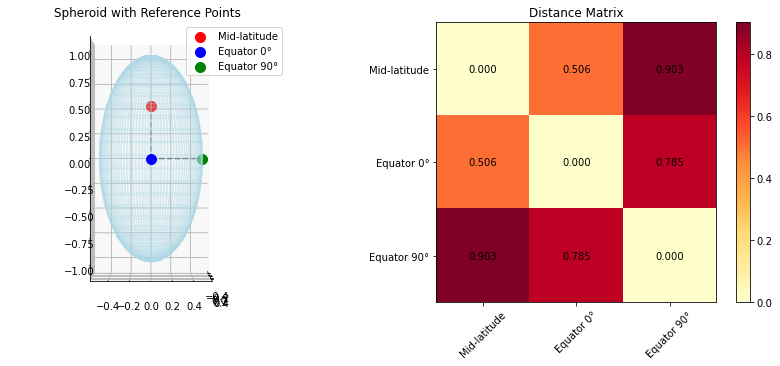


Distances:
Mid-latitude to Equator 0°: 0.506
Mid-latitude to Equator 90°: 0.903
Equator 0° to Equator 90°: 0.785


In [126]:
from geopy.distance import distance as dii
# Create spheroid with a=0.5 and c=1
a = 0.5
c = 1.0
M_spheroid = Spheroid(a=a, c=c)

# Create reference points
mid = np.array([np.sqrt(3)/4, 0, c/2])  # Mid-latitude
equator_0 = np.array([a, 0, 0])   # Point on equator at 0° longitude
equator_90 = np.array([0, a, 0])  # Point on equator at 90° longitude

# Create visualization
fig = plt.figure(figsize=(12, 5))

# First subplot: 3D visualization
ax1 = fig.add_subplot(121, projection='3d')

# Plot spheroid wireframe
x_spheroid, y_spheroid, z_spheroid = create_spheroid_grid(grid_size=50, a=a, c=c)
ax1.plot_wireframe(x_spheroid, y_spheroid, z_spheroid, color='lightblue', alpha=0.3, zorder=0)

# Plot reference points
ax1.scatter(*mid, color='red', s=100, label='Mid-latitude')
ax1.scatter(*equator_0, color='blue', s=100, label='Equator 0°')
ax1.scatter(*equator_90, color='green', s=100, label='Equator 90°')

Axes3D.set_aspect(ax1, 'equal')
# Add lines between points
ax1.plot([mid[0], equator_0[0]], [mid[1], equator_0[1]], 
         [mid[2], equator_0[2]], 'k--', alpha=0.5, zorder=1)
ax1.plot([equator_0[0], equator_90[0]], [equator_0[1], equator_90[1]], 
         [equator_0[2], equator_90[2]], 'k--', alpha=0.5, zorder=1)

ax1.set_title('Spheroid with Reference Points')
ax1.legend()
ax1.view_init(elev=0, azim=0)

# Second subplot: Distance matrix
ax2 = fig.add_subplot(122)

# Calculate distances between points
points = [mid, equator_0, equator_90]
n_points = len(points)
dist_matrix = np.zeros((n_points, n_points))

for i in range(n_points):
    for j in range(n_points):
        dist_matrix[i,j] = M_spheroid.d(points[i], points[j])

# Plot distance matrix
im = ax2.imshow(dist_matrix, cmap='YlOrRd')
plt.colorbar(im)

# Add labels
point_labels = ['Mid-latitude', 'Equator 0°', 'Equator 90°']
ax2.set_xticks(range(n_points))
ax2.set_yticks(range(n_points))
ax2.set_xticklabels(point_labels, rotation=45)
ax2.set_yticklabels(point_labels)
ax2.set_title('Distance Matrix')

# Add distance values as text
for i in range(n_points):
    for j in range(n_points):
        text = ax2.text(j, i, f'{dist_matrix[i, j]:.3f}',
                       ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

# Print the distances
print("\nDistances:")
print(f"Mid-latitude to Equator 0°: {M_spheroid.d(mid, equator_0):.3f}")
print(f"Mid-latitude to Equator 90°: {M_spheroid.d(mid, equator_90):.3f}")
print(f"Equator 0° to Equator 90°: {M_spheroid.d(equator_0, equator_90):.3f}")

In [127]:
def generate_concentrated_sphere_points(n_points, center, kappa=10):
    """Generate points concentrated around a center on unit sphere."""
    # Generate more concentrated angles using von Mises-Fisher distribution
    theta = np.random.vonmises(center[0], kappa, n_points) % (2*np.pi)
    
    # Generate phi with beta distribution
    phi_center = center[1]/np.pi
    a = kappa * phi_center + 1
    b = kappa * (1 - phi_center) + 1
    phi = np.pi * np.random.beta(a, b, n_points)
    
    # Convert to Cartesian coordinates
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    
    return np.column_stack([x, y, z])

In [128]:
n_points = 1000
# Center around (π/4, π/3) - you can change this to concentrate points elsewhere
center = (np.pi, np.pi/2)

points = generate_concentrated_sphere_points(n_points, center, kappa=10)

In [129]:
M_spheroid = Spheroid(a=0.5, c=1.0)
base = d_Tree(split_type='2means', impurity_method='medoid', structure=[(Sphere(dim=2), list(range(3)))],
                        min_split_size=5, mtry=1)
forest = BaggedRegressor(estimator=base, n_estimators=30,
                        bootstrap_fraction=1, bootstrap_replace=True,
                        seed=1, n_jobs=10)
forest.fit(points, MetricData(M_spheroid, sphere_to_spheroid(points, a=0.5, c=1.0)))

BaggedRegressor(bootstrap_fraction=1, bootstrap_replace=True,
                estimator=d_Tree(mtry=1,
                                 structure=[(<pyfrechet.metric_spaces.sphere.Sphere object at 0x14c6fb4f0>,
                                             [0, 1, 2])]),
                n_estimators=30, n_jobs=10, seed=1)

In [130]:
import numpy as np

# Create two points on the unit sphere
p1 = np.array([1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)])  # Point on equator at 0° longitude
p2 = np.array([-1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)])  # Point on equator at 90° longitude

# Normalize to ensure they're on unit sphere
p1 = p1 / np.linalg.norm(p1)
p2 = p2 / np.linalg.norm(p2)

# Create different spheroids:
# 1. Sphere (a=c=1)
# 2. Prolate spheroid (a=0.5, c=1)
# 3. Oblate spheroid (a=1, c=0.5)

# Define parameters
sphere_params = {'a': 1.0, 'c': 1.0}
prolate_params = {'a': 0.5, 'c': 1.0}
oblate_params = {'a': 1.0, 'c': 0.5}

# Create metric spaces
M_sphere = Spheroid(**sphere_params)
M_prolate = Spheroid(**prolate_params)
M_oblate = Spheroid(**oblate_params)

# Map points to each spheroid
p1_sphere = sphere_to_spheroid(p1.reshape(1,-1), **sphere_params)[0]
p2_sphere = sphere_to_spheroid(p2.reshape(1,-1), **sphere_params)[0]

p1_prolate = sphere_to_spheroid(p1.reshape(1,-1), **prolate_params)[0]
p2_prolate = sphere_to_spheroid(p2.reshape(1,-1), **prolate_params)[0]

p1_oblate = sphere_to_spheroid(p1.reshape(1,-1), **oblate_params)[0]
p2_oblate = sphere_to_spheroid(p2.reshape(1,-1), **oblate_params)[0]

# Calculate distances
d_sphere = M_sphere.d(p1_sphere, p2_sphere)
d_prolate = M_prolate.d(p1_prolate, p2_prolate)
d_oblate = M_oblate.d(p1_oblate, p2_oblate)

print("\nOriginal points on unit sphere:")
print(f"p1: {p1}")
print(f"p2: {p2}")

print("\nDistances between points:")
print(f"On sphere (a=c=1):          {d_sphere:.6f}")
print(f"On prolate (a=0.5, c=1):    {d_prolate:.6f}")
print(f"On oblate (a=1, c=0.5):     {d_oblate:.6f}")

print("\nPoints after mapping to each spheroid:")
print("\nSphere points:")
print(f"p1: {p1_sphere}")
print(f"p2: {p2_sphere}")

print("\nProlate spheroid points:")
print(f"p1: {p1_prolate}")
print(f"p2: {p2_prolate}")

print("\nOblate spheroid points:")
print(f"p1: {p1_oblate}")
print(f"p2: {p2_oblate}")


Original points on unit sphere:
p1: [0.57735027 0.57735027 0.57735027]
p2: [-0.57735027  0.57735027  0.57735027]

Distances between points:
On sphere (a=c=1):          1.230959
On prolate (a=0.5, c=1):    0.633393
On oblate (a=1, c=0.5):     1.184585

Points after mapping to each spheroid:

Sphere points:
p1: [0.57735027 0.57735027 0.57735027]
p2: [-0.57735027  0.57735027  0.57735027]

Prolate spheroid points:
p1: [0.28867513 0.28867513 0.57735027]
p2: [-0.28867513  0.28867513  0.57735027]

Oblate spheroid points:
p1: [0.57735027 0.57735027 0.28867513]
p2: [-0.57735027  0.57735027  0.28867513]


#### These plots confirm that using the projected extrinsic Fréchet mean on the spheroid results in exactly the same results on the sphere, regardless of the spheroid considered. Thus, it is better to use medoids, otherwise there is no advantage in considering spheroids.


Fréchet means:
On sphere (a=c=1):        [ 0.99999791 -0.00137313 -0.00151247]
On prolate mapped back:   [ 0.99999791 -0.00137313 -0.00151247]
On oblate mapped back:    [ 0.99999791 -0.00137313 -0.00151247]

Distances between means on sphere:
Sphere to Prolate: 0.000000
Sphere to Oblate:  0.000000
Prolate to Oblate: 0.000000


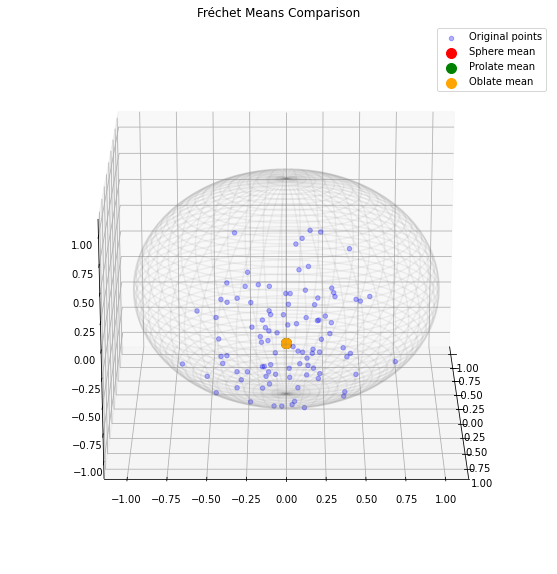

In [131]:
# Set random seed for reproducibility
np.random.seed(42)

def generate_concentrated_sphere_points(n_points=100, center=(0, 0), concentration=10):
    """
    Generate points on unit sphere concentrated around a center point.
    
    Parameters:
    - n_points: number of points to generate
    - center: tuple (theta, phi) in radians for the center of concentration
    - concentration: higher values create more concentrated distributions
    """
    # Generate more concentrated angles using von Mises-Fisher distribution
    theta = np.random.vonmises(center[0], concentration, n_points) % (2*np.pi)
    
    # Generate phi with beta distribution to concentrate around center[1]
    # Map center[1] from [0,pi] to [0,1]
    phi_center = center[1]/np.pi
    a = concentration * phi_center + 1
    b = concentration * (1 - phi_center) + 1
    phi = np.pi * np.random.beta(a, b, n_points)
    
    # Convert to Cartesian coordinates
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    
    return np.column_stack([x, y, z])

# Generate concentrated points on sphere
n_points = 100
# Center around (π/4, π/3) - you can change this to concentrate points elsewhere
center = (0, np.pi/2)

sphere_points = generate_concentrated_sphere_points(n_points, center, concentration=10)

def frechet_mean(points, M, max_iter=100, tol=1e-6):
    """Calculate Fréchet mean of points using metric space M."""
    # Initialize with first point
    current_mean = points[0].copy()
    
    for _ in range(max_iter):
        old_mean = current_mean.copy()
        
        # Calculate gradient step
        grad = np.zeros(3)
        for p in points:
            # Get vector pointing from mean to point
            dist = M.d(current_mean, p)
            if dist > 0:  # Avoid division by zero
                grad += (p - current_mean) / dist
        
        # Update mean
        step_size = 0.1  # You might need to adjust this
        current_mean += step_size * grad
        
        # Project back to surface
        current_mean = current_mean / np.linalg.norm(current_mean)
        
        # Check convergence
        if np.linalg.norm(current_mean - old_mean) < tol:
            break
    
    return current_mean

# Generate points on sphere

# Define different spheroids
sphere_params = {'a': 1.0, 'c': 1.0}      # Sphere
prolate_params = {'a': 0.5, 'c': 100.0}     # Prolate
oblate_params = {'a': 100.0, 'c': 0.5}      # Oblate

# Create metric spaces
M_sphere = Spheroid(**sphere_params)
M_prolate = Spheroid(**prolate_params)
M_oblate = Spheroid(**oblate_params)

prolate_points = sphere_to_spheroid(sphere_points, **prolate_params)
oblate_points = sphere_to_spheroid(sphere_points, **oblate_params)

# Calculate Fréchet mean on sphere
mean_sphere = M_sphere.frechet_mean(sphere_points)

# Map points to prolate and oblate spheroids
mean_prolate = M_prolate.frechet_mean(prolate_points)
mean_oblate =  M_oblate.frechet_mean(oblate_points)

# Map means back to sphere
mean_prolate_sphere = spheroid_to_sphere(mean_prolate, a= 0.5, c= 100.0, R= 1.0)
mean_oblate_sphere = spheroid_to_sphere(mean_oblate, a= 100.0, c= 0.5, R= 1.0)

print("\nFréchet means:")
print(f"On sphere (a=c=1):        {mean_sphere}")
print(f"On prolate mapped back:   {mean_prolate_sphere}")
print(f"On oblate mapped back:    {mean_oblate_sphere}")

# Calculate distances between means on sphere
print("\nDistances between means on sphere:")
print(f"Sphere to Prolate: {M_sphere.d(mean_sphere, mean_prolate_sphere):.6f}")
print(f"Sphere to Oblate:  {M_sphere.d(mean_sphere, mean_oblate_sphere):.6f}")
print(f"Prolate to Oblate: {M_sphere.d(mean_prolate_sphere, mean_oblate_sphere):.6f}")

# Visualize results using matplotlib
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot original points
ax.scatter(sphere_points[:,0], sphere_points[:,1], sphere_points[:,2], 
          color='blue', alpha=0.3, label='Original points')

# Plot means
ax.scatter(*mean_sphere, color='red', s=100, label='Sphere mean')
ax.scatter(*mean_prolate_sphere, color='green', s=100, label='Prolate mean')
ax.scatter(*mean_oblate_sphere, color='orange', s=100, label='Oblate mean')

# Plot unit sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.1)
ax.view_init(elev=20, azim=0)

ax.set_title('Fréchet Means Comparison')
ax.legend()
plt.show()


Fréchet means:
On sphere (a=c=1):        [-0.99951505  0.01392545 -0.02785222]
On prolate mapped back:   [-0.99951505  0.01392545 -0.02785222]
On oblate mapped back:    [-0.99951505  0.01392545 -0.02785222]

Distances between means on sphere:
Sphere to Prolate: 0.000000
Sphere to Oblate:  0.000000
Prolate to Oblate: 0.000000


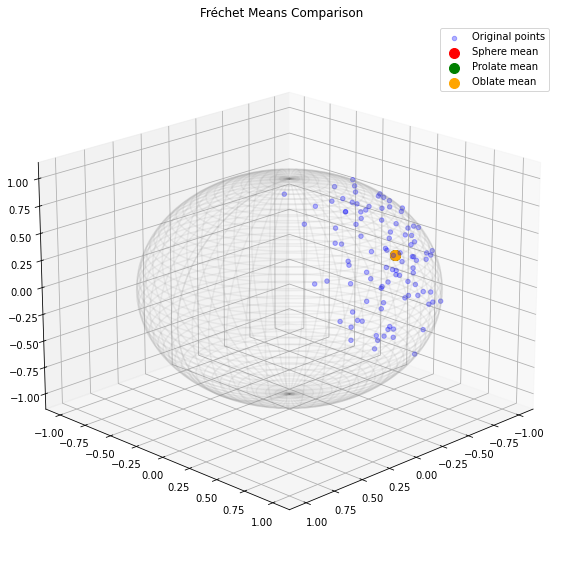

In [ ]:
import numpy as np
from pyfrechet.metric_spaces import Sphere, Spheroid, sphere_to_spheroid, spheroid_to_sphere

# Set random seed for reproducibility
np.random.seed(4)

def generate_concentrated_sphere_points(n_points=100, center=(0, 0), concentration=10):
    """
    Generate points on unit sphere concentrated around a center point.
    
    Parameters:
    - n_points: number of points to generate
    - center: tuple (theta, phi) in radians for the center of concentration
    - concentration: higher values create more concentrated distributions
    """
    # Generate more concentrated angles using von Mises-Fisher distribution
    theta = np.random.vonmises(center[0], concentration, n_points) % (2*np.pi)
    
    # Generate phi with beta distribution to concentrate around center[1]
    # Map center[1] from [0,pi] to [0,1]
    phi_center = center[1]/np.pi
    a = concentration * phi_center + 1
    b = concentration * (1 - phi_center) + 1
    phi = np.pi * np.random.beta(a, b, n_points)
    
    # Convert to Cartesian coordinates
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    
    return np.column_stack([x, y, z])

# Generate concentrated points on sphere
n_points = 100
# Center around (π/4, π/3) - you can change this to concentrate points elsewhere
center = (np.pi, np.pi/2)

sphere_points = generate_concentrated_sphere_points(n_points, center, concentration=10)

def frechet_mean(points, M, max_iter=100, tol=1e-6):
    """Calculate Fréchet mean of points using metric space M."""
    # Initialize with first point
    current_mean = points[0].copy()
    
    for _ in range(max_iter):
        old_mean = current_mean.copy()
        
        # Calculate gradient step
        grad = np.zeros(3)
        for p in points:
            # Get vector pointing from mean to point
            dist = M.d(current_mean, p)
            if dist > 0:  # Avoid division by zero
                grad += (p - current_mean) / dist
        
        # Update mean
        step_size = 0.1  # You might need to adjust this
        current_mean += step_size * grad
        
        # Project back to surface
        current_mean = current_mean / np.linalg.norm(current_mean)
        
        # Check convergence
        if np.linalg.norm(current_mean - old_mean) < tol:
            break
    
    return current_mean

# Generate points on sphere

# Define different spheroids
sphere_params = {'a': 1.0, 'c': 1.0}      # Sphere
prolate_params = {'a': 0.5, 'c': 100.0}     # Prolate
oblate_params = {'a': 100.0, 'c': 0.5}      # Oblate

# Create metric spaces
M_sphere = Spheroid(**sphere_params)
M_prolate = Spheroid(**prolate_params)
M_oblate = Spheroid(**oblate_params)

prolate_points = sphere_to_spheroid(sphere_points, **prolate_params)
oblate_points = sphere_to_spheroid(sphere_points, **oblate_params)

# Calculate Fréchet mean on sphere
mean_sphere = M_sphere.frechet_mean(sphere_points)

# Map points to prolate and oblate spheroids
mean_prolate = M_prolate.frechet_mean(prolate_points)
mean_oblate =  M_oblate.frechet_mean(oblate_points)

# Map means back to sphere
mean_prolate_sphere = spheroid_to_sphere(mean_prolate, a= 0.5, c= 100.0, R= 1.0)
mean_oblate_sphere = spheroid_to_sphere(mean_oblate, a= 100.0, c= 0.5, R= 1.0)

print("\nFréchet means:")
print(f"On sphere (a=c=1):        {mean_sphere}")
print(f"On prolate mapped back:   {mean_prolate_sphere}")
print(f"On oblate mapped back:    {mean_oblate_sphere}")

# Calculate distances between means on sphere
print("\nDistances between means on sphere:")
print(f"Sphere to Prolate: {M_sphere.d(mean_sphere, mean_prolate_sphere):.6f}")
print(f"Sphere to Oblate:  {M_sphere.d(mean_sphere, mean_oblate_sphere):.6f}")
print(f"Prolate to Oblate: {M_sphere.d(mean_prolate_sphere, mean_oblate_sphere):.6f}")

# Visualize results using matplotlib
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot original points
ax.scatter(sphere_points[:,0], sphere_points[:,1], sphere_points[:,2], 
          color='blue', alpha=0.3, label='Original points')

# Plot means
ax.scatter(*mean_sphere, color='red', s=100, label='Sphere mean')
ax.scatter(*mean_prolate_sphere, color='green', s=100, label='Prolate mean')
ax.scatter(*mean_oblate_sphere, color='orange', s=100, label='Oblate mean')

# Plot unit sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.1)
ax.view_init(elev=20, azim=45)

ax.set_title('Fréchet Means Comparison')
ax.legend()
plt.show()

#### Different geometries (sphere-spheroid) impact the splits. That is, even if we fix the centroids, since the distances are different, the clusters change

Number of points with different assignments: 16


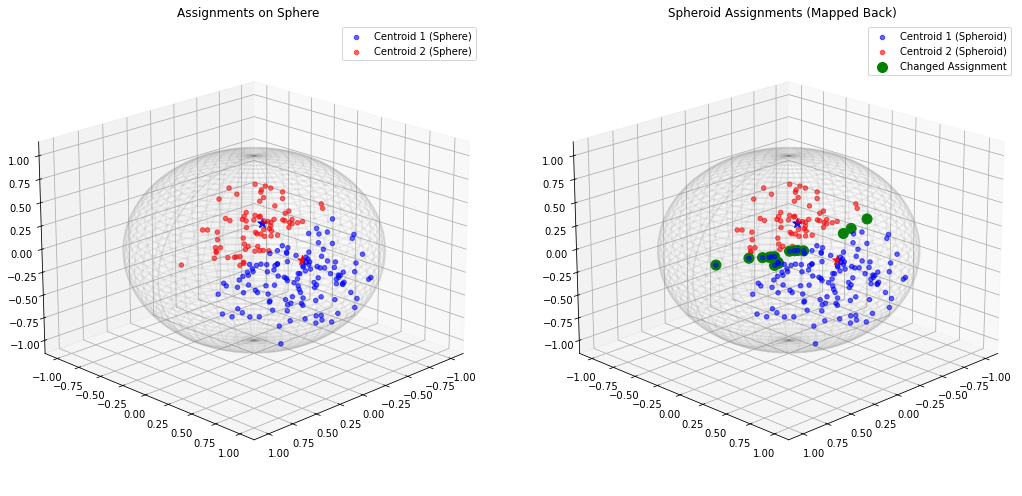


Example points that changed assignment:

Point 6:
Sphere distances:
To centroid 1: 0.3516
To centroid 2: 0.4587
Spheroid distances:
To centroid 1: 0.2914
To centroid 2: 0.2340

Point 8:
Sphere distances:
To centroid 1: 0.4805
To centroid 2: 0.6488
Spheroid distances:
To centroid 1: 0.3529
To centroid 2: 0.3255

Point 17:
Sphere distances:
To centroid 1: 0.2541
To centroid 2: 0.3038
Spheroid distances:
To centroid 1: 0.2245
To centroid 2: 0.1779

Point 18:
Sphere distances:
To centroid 1: 0.7361
To centroid 2: 0.9183
Spheroid distances:
To centroid 1: 0.5111
To centroid 2: 0.4664

Point 20:
Sphere distances:
To centroid 1: 0.2614
To centroid 2: 0.2624
Spheroid distances:
To centroid 1: 0.2299
To centroid 2: 0.1583


In [133]:
import numpy as np
from pyfrechet.metric_spaces import Sphere, Spheroid, sphere_to_spheroid, spheroid_to_sphere
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

def generate_concentrated_sphere_points(n_points, center, kappa=10):
    """Generate points concentrated around a center on unit sphere."""
    # Generate more concentrated angles using von Mises-Fisher distribution
    theta = np.random.vonmises(center[0], kappa, n_points) % (2*np.pi)
    
    # Generate phi with beta distribution
    phi_center = center[1]/np.pi
    a = kappa * phi_center + 1
    b = kappa * (1 - phi_center) + 1
    phi = np.pi * np.random.beta(a, b, n_points)
    
    # Convert to Cartesian coordinates
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    
    return np.column_stack([x, y, z])

# Generate two centroids on sphere (relatively close)
centroid1_angles = (np.pi/4, np.pi/3)  # First centroid
centroid2_angles = (np.pi/4 + 0.5, np.pi/3 + 0.3)  # Second centroid, slightly offset

# Generate points around centroids
n_points = 100
points1 = generate_concentrated_sphere_points(n_points, centroid1_angles, kappa=20)
points2 = generate_concentrated_sphere_points(n_points, centroid2_angles, kappa=20)
sphere_points = np.vstack([points1, points2])

# Generate centroids
centroid1 = generate_concentrated_sphere_points(1, centroid1_angles)[0]
centroid2 = generate_concentrated_sphere_points(1, centroid2_angles)[0]
centroids = np.vstack([centroid1, centroid2])

# Create metric spaces
sphere = Spheroid(a=1.0, c=1.0)  # Sphere
spheroid = Spheroid(a=0.5, c=1.0)  # Prolate spheroid

# Map points and centroids to spheroid
spheroid_points = sphere_to_spheroid(sphere_points, a=0.5, c=1.0)
spheroid_centroids = sphere_to_spheroid(centroids, a=0.5, c=1.0)

# Find closest centroid for each point on sphere
sphere_distances1 = sphere.d(sphere_points, centroid1)
sphere_distances2 = sphere.d(sphere_points, centroid2)
sphere_assignments = (sphere_distances1 < sphere_distances2).astype(int)

# Find closest centroid for each point on spheroid
spheroid_distances1 = spheroid.d(spheroid_points, spheroid_centroids[0])
spheroid_distances2 = spheroid.d(spheroid_points, spheroid_centroids[1])
spheroid_assignments = (spheroid_distances1 < spheroid_distances2).astype(int)

# Find points with different assignments
different_assignments = sphere_assignments != spheroid_assignments
n_different = np.sum(different_assignments)
print(f"Number of points with different assignments: {n_different}")

# Visualization
fig = plt.figure(figsize=(15, 7))

# Plot sphere assignments
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(sphere_points[sphere_assignments==0, 0], 
           sphere_points[sphere_assignments==0, 1],
           sphere_points[sphere_assignments==0, 2],
           c='blue', alpha=0.6, label='Centroid 1 (Sphere)')
ax1.scatter(sphere_points[sphere_assignments==1, 0],
           sphere_points[sphere_assignments==1, 1],
           sphere_points[sphere_assignments==1, 2],
           c='red', alpha=0.6, label='Centroid 2 (Sphere)')
ax1.scatter(*centroid1, c='blue', s=100, marker='*')
ax1.scatter(*centroid2, c='red', s=100, marker='*')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax1.plot_wireframe(x, y, z, color='gray', alpha=0.1)
ax1.set_title('Assignments on Sphere')

# Plot spheroid assignments mapped back to sphere
ax2 = fig.add_subplot(122, projection='3d')
points_back = spheroid_to_sphere(spheroid_points, a=0.5, c=1.0, R=1.0)
ax2.scatter(points_back[spheroid_assignments==0, 0],
           points_back[spheroid_assignments==0, 1],
           points_back[spheroid_assignments==0, 2],
           c='blue', alpha=0.6, label='Centroid 1 (Spheroid)')
ax2.scatter(points_back[spheroid_assignments==1, 0],
           points_back[spheroid_assignments==1, 1],
           points_back[spheroid_assignments==1, 2],
           c='red', alpha=0.6, label='Centroid 2 (Spheroid)')
ax2.scatter(*centroid1, c='blue', s=100, marker='*')
ax2.scatter(*centroid2, c='red', s=100, marker='*')

# Plot sphere wireframe
ax2.plot_wireframe(x, y, z, color='gray', alpha=0.1)
ax2.set_title('Spheroid Assignments (Mapped Back)')

# Highlight points with different assignments
if n_different > 0:
    ax2.scatter(points_back[different_assignments, 0],
               points_back[different_assignments, 1],
               points_back[different_assignments, 2],
               c='green', s=100, alpha=1, marker='o',
               label='Changed Assignment')

ax1.view_init(elev=20, azim=45)
ax2.view_init(elev=20, azim=45)
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()

# Print distances for a few example points that changed assignment
if n_different > 0:
    changed_indices = np.where(different_assignments)[0]
    print("\nExample points that changed assignment:")
    for idx in changed_indices[:5]:  # Show first 5 examples
        print(f"\nPoint {idx}:")
        print("Sphere distances:")
        print(f"To centroid 1: {sphere_distances1[idx]:.4f}")
        print(f"To centroid 2: {sphere_distances2[idx]:.4f}")
        print("Spheroid distances:")
        print(f"To centroid 1: {spheroid_distances1[idx]:.4f}")
        print(f"To centroid 2: {spheroid_distances2[idx]:.4f}")

INFO: n_iter: 1, final variance: 2.4247561023739705, final dist: 0.12552893987856412
INFO: n_iter: 2, final variance: 2.2058700636888955, final dist: 0.06569093769987366
INFO: n_iter: 3, final variance: 2.096207585498038, final dist: 0.028745688483182305
INFO: n_iter: 4, final variance: 2.0503999208828065, final dist: 0.009800764372229443
INFO: n_iter: 5, final variance: 2.0352310803179585, final dist: 0.0029904034127785197
INFO: n_iter: 6, final variance: 2.0305153211209106, final dist: 0.001041767641652993
INFO: n_iter: 7, final variance: 2.0288080202499237, final dist: 0.0004379338268462925
INFO: n_iter: 8, final variance: 2.028073785199976, final dist: 0.00020221296546202034
INFO: n_iter: 8, final variance: 2.027732537129759, final dist: 9.573516674413036e-05
INFO: n_iter: 8, final variance: 2.027732537129759, final dist: 9.573516674413036e-05


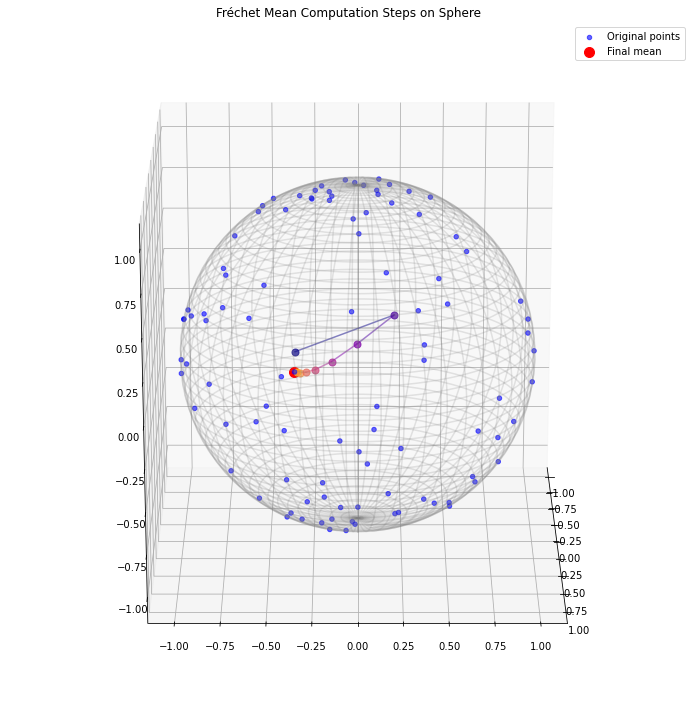

Final Fréchet mean coordinates: [ 0.91117558 -0.3421909   0.22948735]


In [151]:
# Set random seed for reproducibility
np.random.seed(42)

# Create sphere manifold
sphere = Hypersphere(dim=2)


# Generate random points and compute mean steps
points = generate_random_points(n_points=100, seed=42)
mean_steps = visualize_mean_computation(points, weights = np.ones(points.shape[0]), n_steps=10, init=False, seed = 42)

# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot original points
ax.scatter(points[:,0], points[:,1], points[:,2], 
          c='blue', alpha=0.6, label='Original points')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cm.plasma)
sm.set_array([])
#cbar = plt.colorbar(sm)
#cbar.set_label('Step progression', rotation=270, labelpad=15)

ax.view_init(elev=20, azim=0)
ax.set_title('Fréchet Mean Computation Steps on Sphere')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

print("Final Fréchet mean coordinates:", mean_steps[-1])

INFO: n_iter: 1, final variance: 2.035547484179598, final dist: 0.005102465231949194
INFO: n_iter: 2, final variance: 2.0285703854510033, final dist: 0.0006916941822977124
INFO: n_iter: 2, final variance: 2.0276186267856935, final dist: 0.00010213289609814159
INFO: n_iter: 2, final variance: 2.0276186267856935, final dist: 0.00010213289609814159
INFO: n_iter: 2, final variance: 2.0276186267856935, final dist: 0.00010213289609814159
INFO: n_iter: 2, final variance: 2.0276186267856935, final dist: 0.00010213289609814159
INFO: n_iter: 2, final variance: 2.0276186267856935, final dist: 0.00010213289609814159
INFO: n_iter: 2, final variance: 2.0276186267856935, final dist: 0.00010213289609814159
INFO: n_iter: 2, final variance: 2.0276186267856935, final dist: 0.00010213289609814159
INFO: n_iter: 2, final variance: 2.0276186267856935, final dist: 0.00010213289609814159


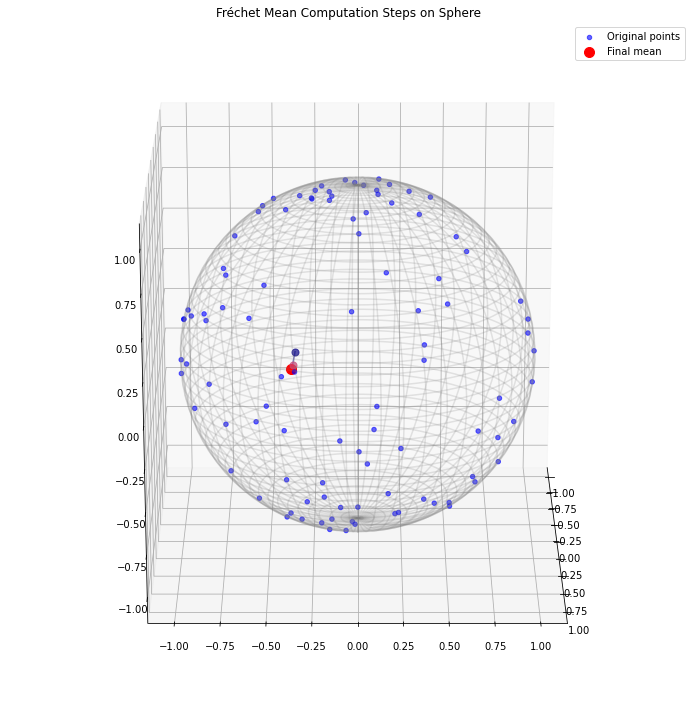

Final Fréchet mean coordinates: [ 0.90178877 -0.35759454  0.24269972]


In [152]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from geomstats.geometry.hypersphere import Hypersphere
from geomstats.learning.frechet_mean import FrechetMean
import matplotlib.cm as cm

# Set random seed for reproducibility
np.random.seed(42)

# Create sphere manifold
sphere = Hypersphere(dim=2)

# Generate random points and compute mean steps
points = generate_random_points(n_points=100, seed=42)
mean_steps = visualize_mean_computation(points, weights = np.ones(points.shape[0]), n_steps=10, init=True, seed = 42)

# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot original points
ax.scatter(points[:,0], points[:,1], points[:,2], 
          c='blue', alpha=0.6, label='Original points')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cm.plasma)
sm.set_array([])
#cbar = plt.colorbar(sm)
#cbar.set_label('Step progression', rotation=270, labelpad=15)

ax.view_init(elev=20, azim=0)
ax.set_title('Fréchet Mean Computation Steps on Sphere')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

print("Final Fréchet mean coordinates:", mean_steps[-1])

INFO: n_iter: 1, final variance: 2.4398292578411467, final dist: 0.13700780307953364
INFO: n_iter: 2, final variance: 2.228538499514834, final dist: 0.039801240911767934
INFO: n_iter: 3, final variance: 2.1693751428014965, final dist: 0.00980149025593582
INFO: n_iter: 4, final variance: 2.1540061068454626, final dist: 0.003499178262987057
INFO: n_iter: 5, final variance: 2.148157022696741, final dist: 0.0016025218850863052
INFO: n_iter: 6, final variance: 2.1454672299106656, final dist: 0.0007371914966430099
INFO: n_iter: 7, final variance: 2.144231669424687, final dist: 0.00033781020477715256
INFO: n_iter: 7, final variance: 2.1436638483181354, final dist: 0.00015729666638375373
INFO: n_iter: 7, final variance: 2.1436638483181354, final dist: 0.00015729666638375373
INFO: n_iter: 7, final variance: 2.1436638483181354, final dist: 0.00015729666638375373


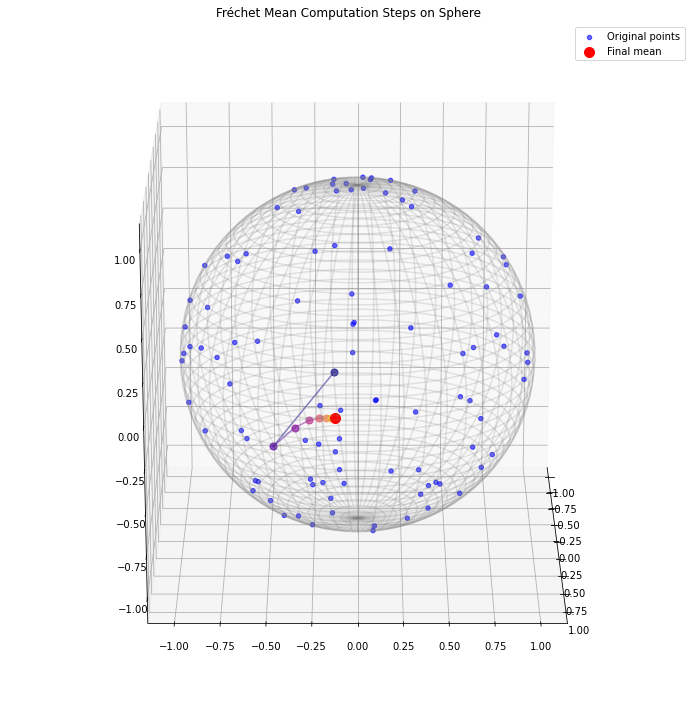

Final Fréchet mean coordinates: [ 0.99240582 -0.12298879 -0.00210747]


In [154]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from geomstats.geometry.hypersphere import Hypersphere
from geomstats.learning.frechet_mean import FrechetMean
import matplotlib.cm as cm

# Set random seed for reproducibility
np.random.seed(1)

# Create sphere manifold
sphere = Hypersphere(dim=2)
# Generate random points and compute mean steps
points = generate_random_points(n_points=100, seed=1)
mean_steps = visualize_mean_computation(points, weights = np.ones(points.shape[0]), n_steps=10, init=False, seed = 1)


# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot original points
ax.scatter(points[:,0], points[:,1], points[:,2], 
          c='blue', alpha=0.6, label='Original points')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cm.plasma)
sm.set_array([])
#cbar = plt.colorbar(sm)
#cbar.set_label('Step progression', rotation=270, labelpad=15)

ax.view_init(elev=20, azim=0)
ax.set_title('Fréchet Mean Computation Steps on Sphere')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

print("Final Fréchet mean coordinates:", mean_steps[-1])

INFO: n_iter: 1, final variance: 2.170809995022211, final dist: 0.00964001061273429
INFO: n_iter: 2, final variance: 2.1548717278687, final dist: 0.004337899880045079
INFO: n_iter: 3, final variance: 2.1475821793137, final dist: 0.001918791677570732
INFO: n_iter: 4, final variance: 2.144540773754477, final dist: 0.0006340503762159465
INFO: n_iter: 4, final variance: 2.1435680891116315, final dist: 0.00018139299121960293
INFO: n_iter: 4, final variance: 2.1435680891116315, final dist: 0.00018139299121960293
INFO: n_iter: 4, final variance: 2.1435680891116315, final dist: 0.00018139299121960293
INFO: n_iter: 4, final variance: 2.1435680891116315, final dist: 0.00018139299121960293
INFO: n_iter: 4, final variance: 2.1435680891116315, final dist: 0.00018139299121960293
INFO: n_iter: 4, final variance: 2.1435680891116315, final dist: 0.00018139299121960293


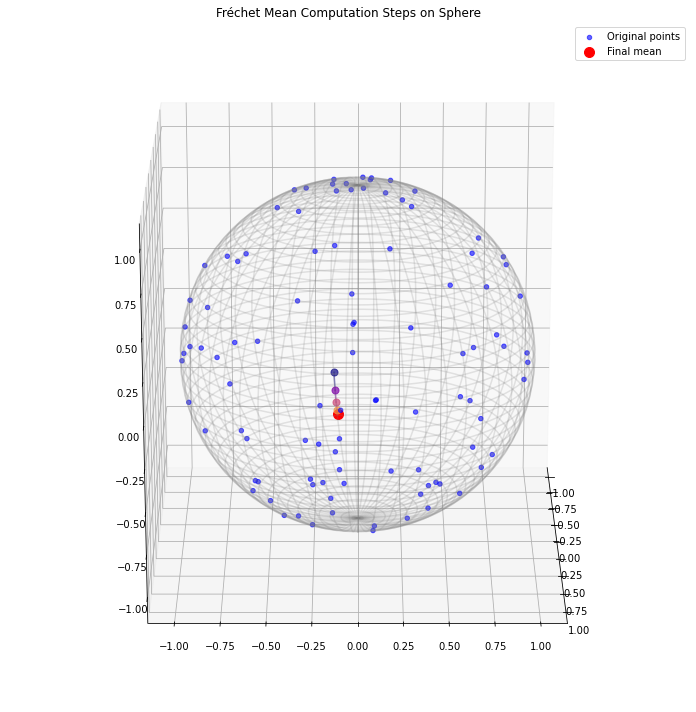

Final Fréchet mean coordinates: [ 0.99446001 -0.10342717  0.01876435]


In [157]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from geomstats.geometry.hypersphere import Hypersphere
from geomstats.learning.frechet_mean import FrechetMean
import matplotlib.cm as cm

# Set random seed for reproducibility
np.random.seed(1)

# Create sphere manifold
sphere = Hypersphere(dim=2)
# Generate random points and compute mean steps
points = generate_random_points(n_points=100, seed=1)
mean_steps = visualize_mean_computation(points, weights = np.ones(points.shape[0]), n_steps=10, init=True, seed = 1)


# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot original points
ax.scatter(points[:,0], points[:,1], points[:,2], 
          c='blue', alpha=0.6, label='Original points')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cm.plasma)
sm.set_array([])
#cbar = plt.colorbar(sm)
#cbar.set_label('Step progression', rotation=270, labelpad=15)

ax.view_init(elev=20, azim=0)
ax.set_title('Fréchet Mean Computation Steps on Sphere')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

print("Final Fréchet mean coordinates:", mean_steps[-1])

INFO: n_iter: 1, final variance: 2.344447686898682, final dist: 0.004809613947518052
INFO: n_iter: 2, final variance: 2.3369715230478385, final dist: 0.0014948814056566638
INFO: n_iter: 3, final variance: 2.334635696882251, final dist: 0.00048379540253996444
INFO: n_iter: 3, final variance: 2.333868045088656, final dist: 0.00017146064306541536
INFO: n_iter: 3, final variance: 2.333868045088656, final dist: 0.00017146064306541536
INFO: n_iter: 3, final variance: 2.333868045088656, final dist: 0.00017146064306541536
INFO: n_iter: 3, final variance: 2.333868045088656, final dist: 0.00017146064306541536
INFO: n_iter: 3, final variance: 2.333868045088656, final dist: 0.00017146064306541536
INFO: n_iter: 3, final variance: 2.333868045088656, final dist: 0.00017146064306541536
INFO: n_iter: 3, final variance: 2.333868045088656, final dist: 0.00017146064306541536


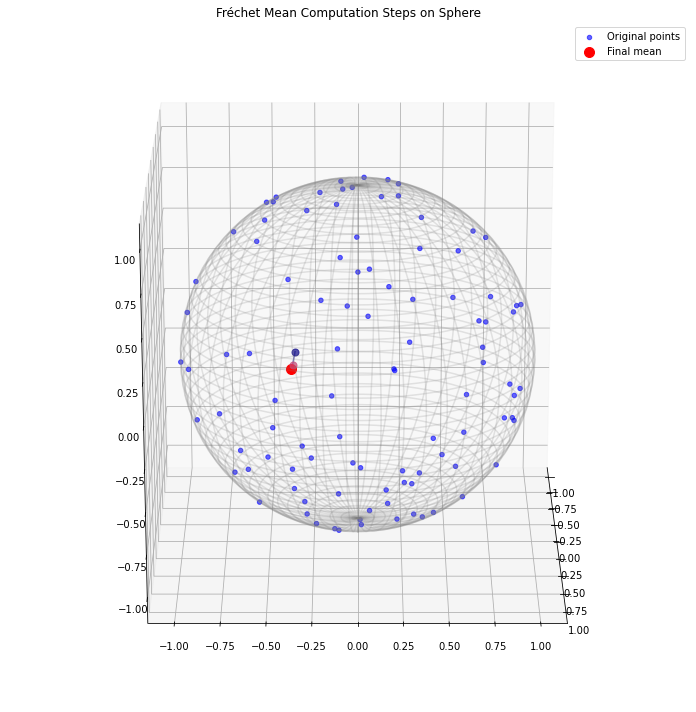

Final Fréchet mean coordinates: [ 0.90178877 -0.35759454  0.24269972]


In [153]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from geomstats.geometry.hypersphere import Hypersphere
from geomstats.learning.frechet_mean import FrechetMean
import matplotlib.cm as cm

# Set random seed for reproducibility
np.random.seed(7)

# Create sphere manifold
sphere = Hypersphere(dim=2)

# Generate random points and compute mean steps
points = generate_random_points(n_points=100, seed=7)
visualize_mean_computation(points, weights = np.ones(points.shape[0]), n_steps=10, init=True, seed = 7)


# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot original points
ax.scatter(points[:,0], points[:,1], points[:,2], 
          c='blue', alpha=0.6, label='Original points')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cm.plasma)
sm.set_array([])
#cbar = plt.colorbar(sm)
#cbar.set_label('Step progression', rotation=270, labelpad=15)

ax.view_init(elev=20, azim=0)
ax.set_title('Fréchet Mean Computation Steps on Sphere')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

print("Final Fréchet mean coordinates:", mean_steps[-1])

INFO: n_iter: 1, final variance: 2.4585695267146823, final dist: 0.029904960259507188
INFO: n_iter: 2, final variance: 2.40940082596203, final dist: 0.015891253915341394
INFO: n_iter: 3, final variance: 2.378486671938505, final dist: 0.013221566326890494
INFO: n_iter: 4, final variance: 2.355353553948356, final dist: 0.007089905374860493
INFO: n_iter: 5, final variance: 2.3434473201438704, final dist: 0.003249871615804081
INFO: n_iter: 6, final variance: 2.3380199408395272, final dist: 0.0014667824599550127
INFO: n_iter: 7, final variance: 2.335560713456041, final dist: 0.0006757675430180257
INFO: n_iter: 8, final variance: 2.3344223773129427, final dist: 0.0003180434403706578
INFO: n_iter: 8, final variance: 2.333884848291004, final dist: 0.00015186534188282774
INFO: n_iter: 8, final variance: 2.333884848291004, final dist: 0.00015186534188282774


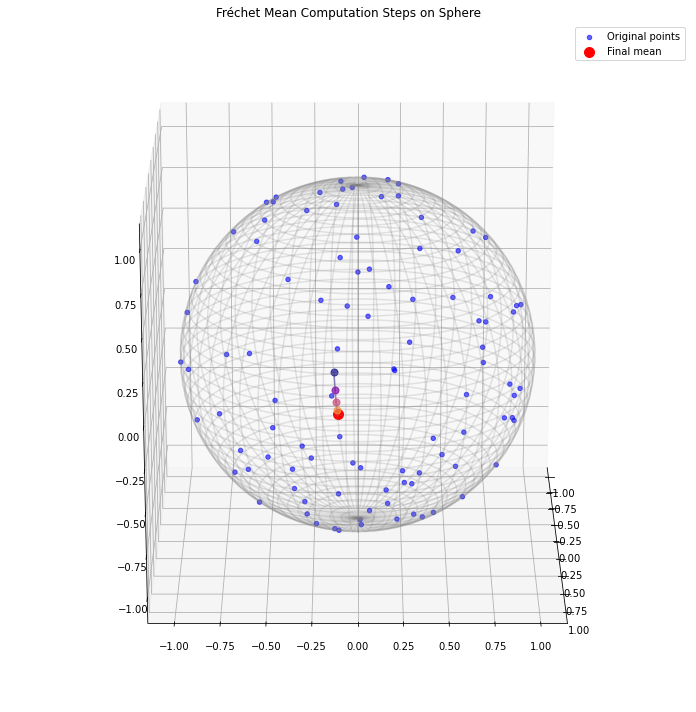

Final Fréchet mean coordinates: [ 0.99446001 -0.10342717  0.01876435]


In [156]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from geomstats.geometry.hypersphere import Hypersphere
from geomstats.learning.frechet_mean import FrechetMean
import matplotlib.cm as cm

# Set random seed for reproducibility
np.random.seed(7)

# Create sphere manifold
sphere = Hypersphere(dim=2)

# Generate random points and compute mean steps
points = generate_random_points(n_points=100, seed=7)
visualize_mean_computation(points, weights = np.ones(points.shape[0]), n_steps=10, init=False, seed = 7)


# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot original points
ax.scatter(points[:,0], points[:,1], points[:,2], 
          c='blue', alpha=0.6, label='Original points')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cm.plasma)
sm.set_array([])
#cbar = plt.colorbar(sm)
#cbar.set_label('Step progression', rotation=270, labelpad=15)

ax.view_init(elev=20, azim=0)
ax.set_title('Fréchet Mean Computation Steps on Sphere')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

print("Final Fréchet mean coordinates:", mean_steps[-1])

#### Real cases in the sphere simulations where the max number of iterations was reached

INFO: n_iter: 1, final variance: 1.633172176934749, final dist: 0.00040332321204838533
INFO: n_iter: 2, final variance: 1.6322984452613682, final dist: 0.000542931953187323
INFO: n_iter: 3, final variance: 1.6311587504567528, final dist: 0.0006381288544079002
INFO: n_iter: 4, final variance: 1.630517136388465, final dist: 0.0006470095115062951
INFO: n_iter: 5, final variance: 1.6301943384681334, final dist: 0.0006401554639698818
INFO: n_iter: 6, final variance: 1.6300346604526021, final dist: 0.0006341086995528575
INFO: n_iter: 7, final variance: 1.6299555083253698, final dist: 0.0006304778788677404
INFO: n_iter: 8, final variance: 1.6299161338461956, final dist: 0.0006285175736427781
INFO: n_iter: 9, final variance: 1.629896500575637, final dist: 0.0006275021193548766
INFO: n_iter: 10, final variance: 1.6298866978686761, final dist: 0.0006269856848564004
INFO: n_iter: 11, final variance: 1.6298818000511088, final dist: 0.0006267253056894316
INFO: n_iter: 12, final variance: 1.62987935

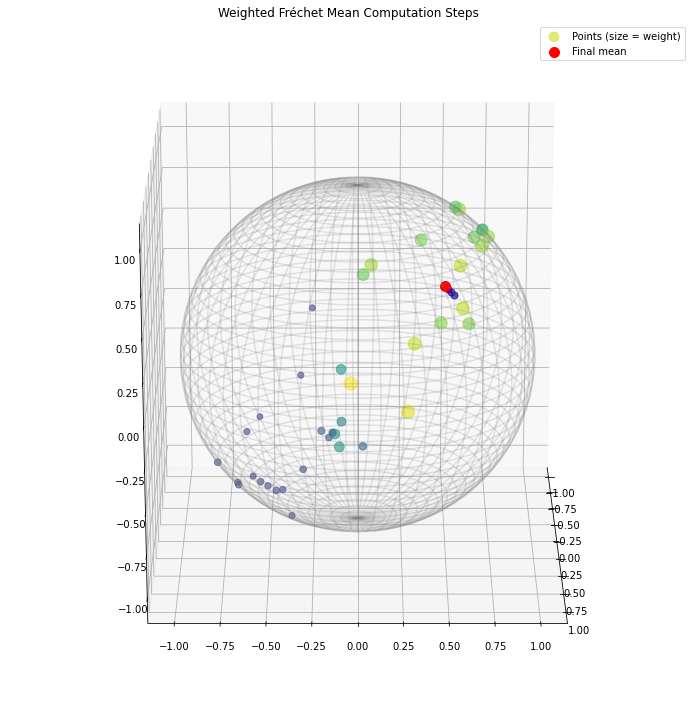

In [258]:
# Load points and weights from CSV files
i = 0  # Change this to visualize different scenarios (0-3)
points = pd.read_csv(f'frechet_points_{i}.csv', header=None).values
weights = pd.read_csv(f'frechet_weights_{i}.csv', header=None).values.squeeze()

# Calculate mean steps
mean_steps = visualize_mean_computation(points, weights=weights, n_steps=32, init=True)

# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot spher<e wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot points with size proportional to weights
sizes = (weights - weights.min()) * (180 / (weights.max() - weights.min() + 1e-10))
scatter = ax.scatter(points[:,0], points[:,1], points[:,2], 
                    s=sizes, c=weights, cmap='viridis',
                    alpha=0.6, label='Points (size = weight)')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

ax.view_init(elev=20, azim=0)
ax.set_title('Weighted Fréchet Mean Computation Steps')
ax.legend()
ax.set_box_aspect([1,1,1])
plt.tight_layout()
plt.show()

INFO: n_iter: 0, final variance: 0.0, final dist: 0.0
INFO: n_iter: 1, final variance: 1.7652331098780039, final dist: 0.09453549360081925
INFO: n_iter: 2, final variance: 1.6371357663566175, final dist: 0.005902447811397124
INFO: n_iter: 3, final variance: 1.6302947663019893, final dist: 0.0006625036786420846
INFO: n_iter: 4, final variance: 1.6290222348436165, final dist: 0.0005585030452342498
INFO: n_iter: 5, final variance: 1.6279757515773983, final dist: 0.0004177156263024397
INFO: n_iter: 6, final variance: 1.6272131596504233, final dist: 0.0002806029949401905
INFO: n_iter: 6, final variance: 1.6267099377758092, final dist: 0.00017483472732148303
INFO: n_iter: 6, final variance: 1.6267099377758092, final dist: 0.00017483472732148303
INFO: n_iter: 6, final variance: 1.6267099377758092, final dist: 0.00017483472732148303
INFO: n_iter: 6, final variance: 1.6267099377758092, final dist: 0.00017483472732148303
INFO: n_iter: 6, final variance: 1.6267099377758092, final dist: 0.00017483

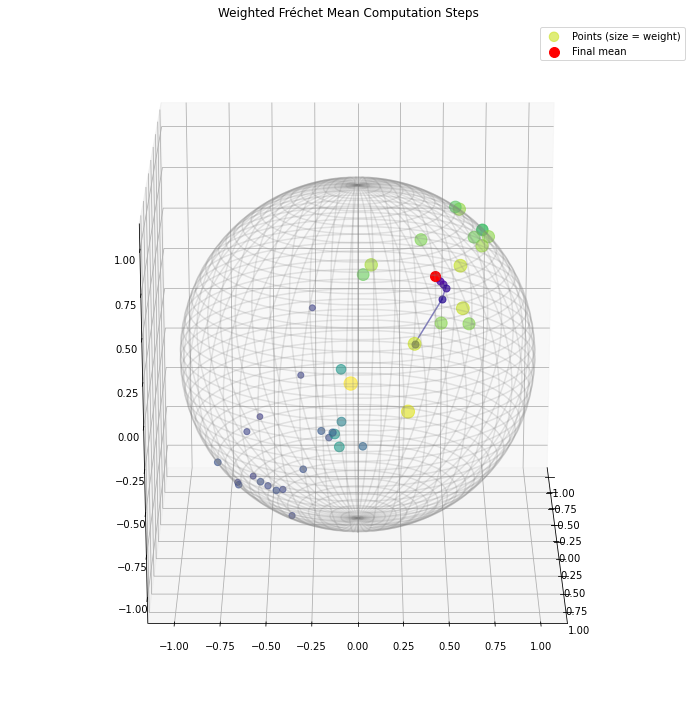

In [255]:
# Load points and weights from CSV files
i = 0  # Change this to visualize different scenarios (0-3)
points = pd.read_csv(f'frechet_points_{i}.csv', header=None).values
weights = pd.read_csv(f'frechet_weights_{i}.csv', header=None).values.squeeze()

# Calculate mean steps
mean_steps = visualize_mean_computation(points, weights=weights, n_steps=32, init=False)

# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot points with size proportional to weights
sizes = (weights - weights.min()) * (180 / (weights.max() - weights.min() + 1e-10))
scatter = ax.scatter(points[:,0], points[:,1], points[:,2], 
                    s=sizes, c=weights, cmap='viridis',
                    alpha=0.6, label='Points (size = weight)')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

ax.view_init(elev=20, azim=0)
ax.set_title('Weighted Fréchet Mean Computation Steps')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

INFO: n_iter: 0, final variance: 0.0, final dist: 0.0
INFO: n_iter: 1, final variance: 6.043440268223601, final dist: 0.03371165726077531
INFO: n_iter: 2, final variance: 5.837949574580618, final dist: 0.8177606372674727
INFO: n_iter: 3, final variance: 3.4371181313404673, final dist: 1.7575312792930042
INFO: n_iter: 4, final variance: 1.9283531776791067, final dist: 0.8583453203162449
INFO: n_iter: 5, final variance: 1.5369221897748047, final dist: 0.5814484330779762
INFO: n_iter: 6, final variance: 1.3981316967831499, final dist: 0.48091377542054253
INFO: n_iter: 7, final variance: 1.3393867520881966, final dist: 0.43807335269346154
INFO: n_iter: 8, final variance: 1.312319883020529, final dist: 0.41828396485835756
INFO: n_iter: 9, final variance: 1.2993232481952088, final dist: 0.4087711439745679
INFO: n_iter: 10, final variance: 1.2929544693230006, final dist: 0.4041071234325207
INFO: n_iter: 11, final variance: 1.2898018991100402, final dist: 0.40179783515495837
INFO: n_iter: 12, 

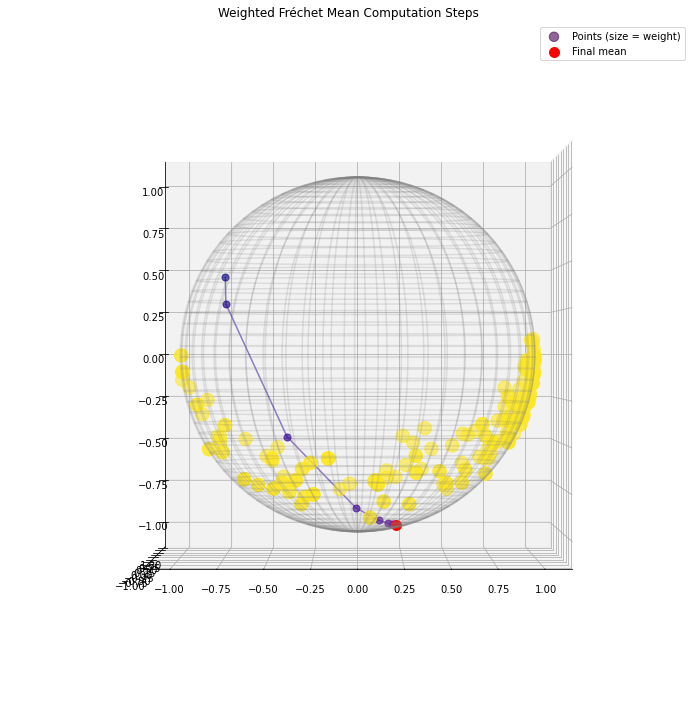

In [259]:
# Load points and weights from CSV files
i = 1  # Change this to visualize different scenarios (0-3)
points = pd.read_csv(f'frechet_points_{i}.csv', header=None).values
weights = pd.read_csv(f'frechet_weights_{i}.csv', header=None).values.squeeze()

# Calculate mean steps
mean_steps = visualize_mean_computation(points, weights=weights, n_steps=32, init=False)

# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot points with size proportional to weights
sizes = (weights - weights.min()) * (180 / (weights.max() - weights.min() + 1e-10))
scatter = ax.scatter(points[:,0], points[:,1], points[:,2], 
                    s=sizes, c=weights, cmap='viridis',
                    alpha=0.6, label='Points (size = weight)')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

ax.view_init(elev=0, azim=-90)
ax.set_title('Weighted Fréchet Mean Computation Steps')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

INFO: n_iter: 1, final variance: 0.7498362231909256, final dist: 0.005666529285400744
INFO: n_iter: 1, final variance: 0.7441151880685579, final dist: 1.0386163137731317e-06
INFO: n_iter: 1, final variance: 0.7441151880685579, final dist: 1.0386163137731317e-06
INFO: n_iter: 1, final variance: 0.7441151880685579, final dist: 1.0386163137731317e-06
INFO: n_iter: 1, final variance: 0.7441151880685579, final dist: 1.0386163137731317e-06
INFO: n_iter: 1, final variance: 0.7441151880685579, final dist: 1.0386163137731317e-06
INFO: n_iter: 1, final variance: 0.7441151880685579, final dist: 1.0386163137731317e-06
INFO: n_iter: 1, final variance: 0.7441151880685579, final dist: 1.0386163137731317e-06
INFO: n_iter: 1, final variance: 0.7441151880685579, final dist: 1.0386163137731317e-06
INFO: n_iter: 1, final variance: 0.7441151880685579, final dist: 1.0386163137731317e-06
INFO: n_iter: 1, final variance: 0.7441151880685579, final dist: 1.0386163137731317e-06
INFO: n_iter: 1, final variance: 0

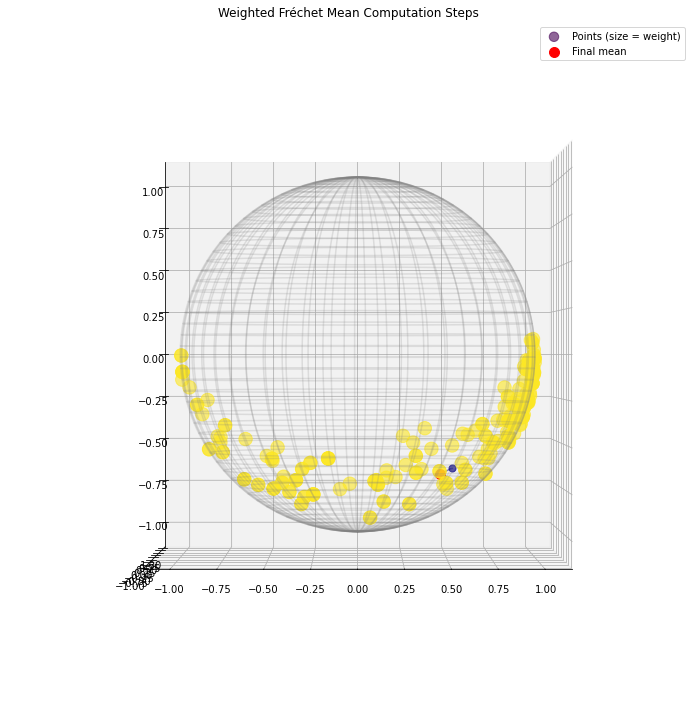

In [246]:
# Load points and weights from CSV files
i = 1  # Change this to visualize different scenarios (0-3)
points = pd.read_csv(f'frechet_points_{i}.csv', header=None).values
weights = pd.read_csv(f'frechet_weights_{i}.csv', header=None).values.squeeze()

# Calculate mean steps
mean_steps = visualize_mean_computation(points, weights=weights, n_steps=32, init=True)

# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot points with size proportional to weights
sizes = (weights - weights.min()) * (180 / (weights.max() - weights.min() + 1e-10))
scatter = ax.scatter(points[:,0], points[:,1], points[:,2], 
                    s=sizes, c=weights, cmap='viridis',
                    alpha=0.6, label='Points (size = weight)')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

ax.view_init(elev=0, azim=-90)
ax.set_title('Weighted Fréchet Mean Computation Steps')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

INFO: n_iter: 0, final variance: 0.0, final dist: 0.0
INFO: n_iter: 1, final variance: 6.2415524509074904, final dist: 0.04960565857004852
INFO: n_iter: 2, final variance: 5.980866982200423, final dist: 0.9291125850728791
INFO: n_iter: 3, final variance: 3.4229678619212764, final dist: 1.7534788707029207
INFO: n_iter: 4, final variance: 1.8988419978960376, final dist: 0.9059786933340005
INFO: n_iter: 5, final variance: 1.4840319556889552, final dist: 0.6238563248277298
INFO: n_iter: 6, final variance: 1.3349235295233721, final dist: 0.5186915525277851
INFO: n_iter: 7, final variance: 1.2715321772012267, final dist: 0.47342622530870815
INFO: n_iter: 8, final variance: 1.2422747195259005, final dist: 0.4524252602792514
INFO: n_iter: 9, final variance: 1.2282158857226193, final dist: 0.4423094883456423
INFO: n_iter: 10, final variance: 1.2213242448272097, final dist: 0.43734498132210103
INFO: n_iter: 11, final variance: 1.2179122968566922, final dist: 0.4348857293165132
INFO: n_iter: 12, 

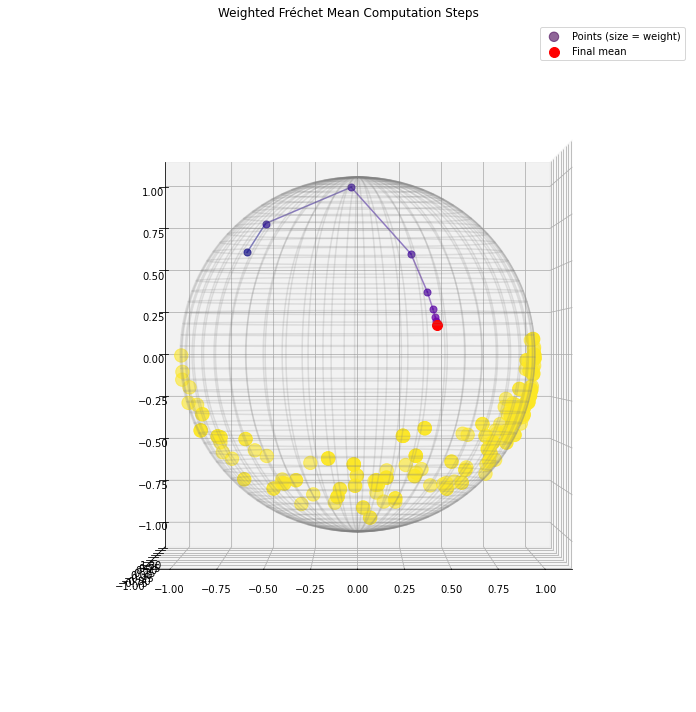

In [247]:
# Load points and weights from CSV files
i = 2  # Change this to visualize different scenarios (0-3)
points = pd.read_csv(f'frechet_points_{i}.csv', header=None).values
weights = pd.read_csv(f'frechet_weights_{i}.csv', header=None).values.squeeze()

# Calculate mean steps
mean_steps = visualize_mean_computation(points, weights=weights, n_steps=32, init=False)

# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot points with size proportional to weights
sizes = (weights - weights.min()) * (180 / (weights.max() - weights.min() + 1e-10))
scatter = ax.scatter(points[:,0], points[:,1], points[:,2], 
                    s=sizes, c=weights, cmap='viridis',
                    alpha=0.6, label='Points (size = weight)')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

ax.view_init(elev=0, azim=-90)
ax.set_title('Weighted Fréchet Mean Computation Steps')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

INFO: n_iter: 1, final variance: 0.6371028830005634, final dist: 0.003217571148787083
INFO: n_iter: 1, final variance: 0.6338585923199861, final dist: 3.6552790932469394e-07
INFO: n_iter: 1, final variance: 0.6338585923199861, final dist: 3.6552790932469394e-07
INFO: n_iter: 1, final variance: 0.6338585923199861, final dist: 3.6552790932469394e-07
INFO: n_iter: 1, final variance: 0.6338585923199861, final dist: 3.6552790932469394e-07
INFO: n_iter: 1, final variance: 0.6338585923199861, final dist: 3.6552790932469394e-07
INFO: n_iter: 1, final variance: 0.6338585923199861, final dist: 3.6552790932469394e-07
INFO: n_iter: 1, final variance: 0.6338585923199861, final dist: 3.6552790932469394e-07
INFO: n_iter: 1, final variance: 0.6338585923199861, final dist: 3.6552790932469394e-07
INFO: n_iter: 1, final variance: 0.6338585923199861, final dist: 3.6552790932469394e-07
INFO: n_iter: 1, final variance: 0.6338585923199861, final dist: 3.6552790932469394e-07
INFO: n_iter: 1, final variance: 0

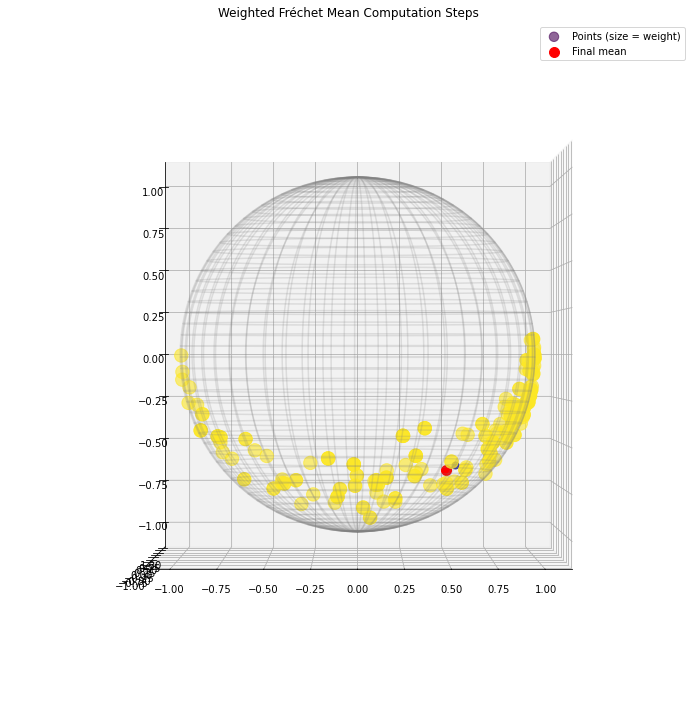

In [248]:
# Load points and weights from CSV files
i = 2  # Change this to visualize different scenarios (0-3)
points = pd.read_csv(f'frechet_points_{i}.csv', header=None).values
weights = pd.read_csv(f'frechet_weights_{i}.csv', header=None).values.squeeze()

# Calculate mean steps
mean_steps = visualize_mean_computation(points, weights=weights, n_steps=32, init=True)

# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot points with size proportional to weights
sizes = (weights - weights.min()) * (180 / (weights.max() - weights.min() + 1e-10))
scatter = ax.scatter(points[:,0], points[:,1], points[:,2], 
                    s=sizes, c=weights, cmap='viridis',
                    alpha=0.6, label='Points (size = weight)')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

ax.view_init(elev=0, azim=-90)
ax.set_title('Weighted Fréchet Mean Computation Steps')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

INFO: n_iter: 0, final variance: 0.0, final dist: 0.0
INFO: n_iter: 1, final variance: 6.651667065303583, final dist: 0.030624087055163465
INFO: n_iter: 2, final variance: 6.541131731788806, final dist: 0.24917376409323053
INFO: n_iter: 3, final variance: 5.396425059766286, final dist: 2.8262120688803227
INFO: n_iter: 4, final variance: 2.5435163979685607, final dist: 1.8610309695900595
INFO: n_iter: 5, final variance: 1.725025934674744, final dist: 1.071019734229014
INFO: n_iter: 6, final variance: 1.4735506041826716, final dist: 0.8262968162645322
INFO: n_iter: 7, final variance: 1.373409176059445, final dist: 0.7286913765730813
INFO: n_iter: 8, final variance: 1.3285598754494083, final dist: 0.6849562329609254
INFO: n_iter: 9, final variance: 1.307318093798246, final dist: 0.6642381328946279
INFO: n_iter: 10, final variance: 1.2969789184698568, final dist: 0.6541529940427393
INFO: n_iter: 11, final variance: 1.291878084894671, final dist: 0.6491772910280186
INFO: n_iter: 12, final v

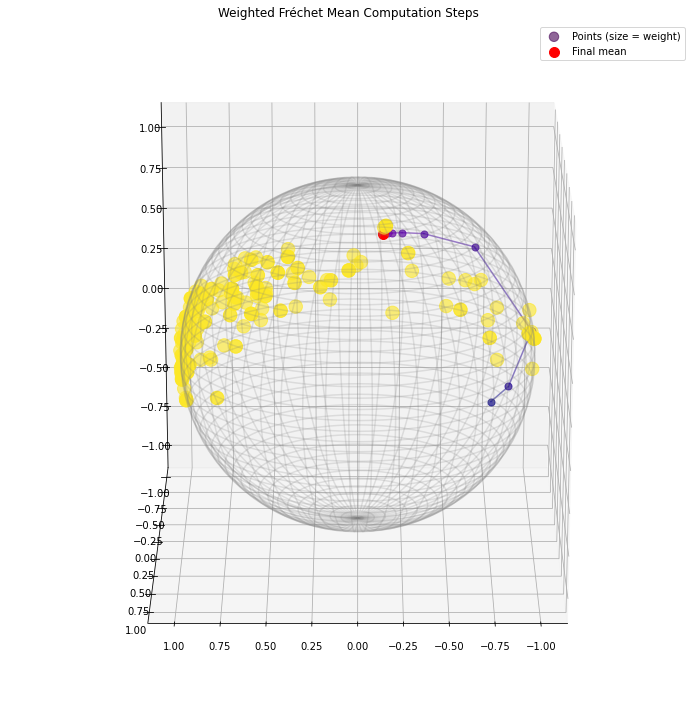

In [249]:
# Load points and weights from CSV files
i = 3  # Change this to visualize different scenarios (0-3)
points = pd.read_csv(f'frechet_points_{i}.csv', header=None).values
weights = pd.read_csv(f'frechet_weights_{i}.csv', header=None).values.squeeze()

# Calculate mean steps
mean_steps = visualize_mean_computation(points, weights=weights, n_steps=32, init=False)

# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot points with size proportional to weights
sizes = (weights - weights.min()) * (180 / (weights.max() - weights.min() + 1e-10))
scatter = ax.scatter(points[:,0], points[:,1], points[:,2], 
                    s=sizes, c=weights, cmap='viridis',
                    alpha=0.6, label='Points (size = weight)')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

ax.view_init(elev=20, azim=90)
ax.set_title('Weighted Fréchet Mean Computation Steps')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

INFO: n_iter: 1, final variance: 0.633598670991085, final dist: 0.00847679473667268
INFO: n_iter: 1, final variance: 0.625040541636647, final dist: 1.4347115718149132e-06
INFO: n_iter: 1, final variance: 0.625040541636647, final dist: 1.4347115718149132e-06
INFO: n_iter: 1, final variance: 0.625040541636647, final dist: 1.4347115718149132e-06
INFO: n_iter: 1, final variance: 0.625040541636647, final dist: 1.4347115718149132e-06
INFO: n_iter: 1, final variance: 0.625040541636647, final dist: 1.4347115718149132e-06
INFO: n_iter: 1, final variance: 0.625040541636647, final dist: 1.4347115718149132e-06
INFO: n_iter: 1, final variance: 0.625040541636647, final dist: 1.4347115718149132e-06
INFO: n_iter: 1, final variance: 0.625040541636647, final dist: 1.4347115718149132e-06
INFO: n_iter: 1, final variance: 0.625040541636647, final dist: 1.4347115718149132e-06
INFO: n_iter: 1, final variance: 0.625040541636647, final dist: 1.4347115718149132e-06
INFO: n_iter: 1, final variance: 0.62504054163

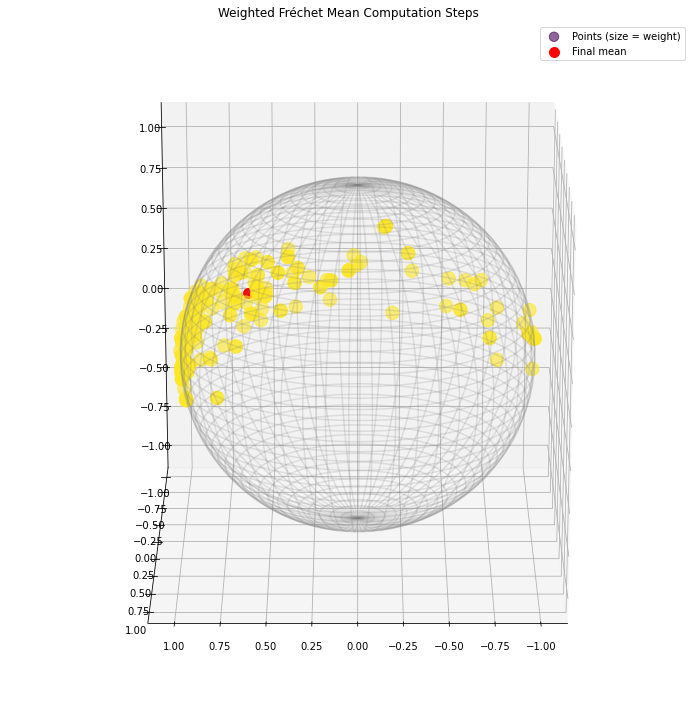

In [250]:
# Load points and weights from CSV files
i = 3  # Change this to visualize different scenarios (0-3)
points = pd.read_csv(f'frechet_points_{i}.csv', header=None).values
weights = pd.read_csv(f'frechet_weights_{i}.csv', header=None).values.squeeze()

# Calculate mean steps
mean_steps = visualize_mean_computation(points, weights=weights, n_steps=32, init=True)

# Create visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere wireframe
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

# Plot points with size proportional to weights
sizes = (weights - weights.min()) * (180 / (weights.max() - weights.min() + 1e-10))
scatter = ax.scatter(points[:,0], points[:,1], points[:,2], 
                    s=sizes, c=weights, cmap='viridis',
                    alpha=0.6, label='Points (size = weight)')

# Plot mean evolution with color gradient
colors = cm.plasma(np.linspace(0, 1, len(mean_steps)))
for i, (mean, color) in enumerate(zip(mean_steps, colors)):
    if i < len(mean_steps) - 1:  # All points except the last
        ax.scatter(mean[0], mean[1], mean[2], 
                  color=color, alpha=0.7, s=50)
    else:  # Last point (final mean)
        ax.scatter(mean[0], mean[1], mean[2], 
                  color='red', s=100, label='Final mean')

# Connect mean points with lines
for i in range(len(mean_steps)-1):
    ax.plot([mean_steps[i,0], mean_steps[i+1,0]],
            [mean_steps[i,1], mean_steps[i+1,1]],
            [mean_steps[i,2], mean_steps[i+1,2]],
            color=colors[i], alpha=0.5)

ax.view_init(elev=20, azim=90)
ax.set_title('Weighted Fréchet Mean Computation Steps')
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()